# ECON3203 Group Project: Sensational

## Explore & Prepare data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# load data
sample_url="https://drive.google.com/uc?export=download&id=1ekCjJOTjGD0OASErwVnwhJuPD0hFfCEF"
out_url=sample_url
db_sample = pd.read_csv(sample_url)
db_out = pd.read_csv(out_url)

In [ ]:
db_sample.head()

In [ ]:
# Simple data stats
db_sample.describe(include="all")

- count → number of valid (non-missing) values
- unique → number of distinct categories (categorical data only)
- top → modal (most common) category
- freq → how often that top category appears


In [ ]:
# Categorical exploration
categorical_cols = db_sample.select_dtypes(include='object').columns

for col in categorical_cols:
    print(db_sample[col].value_counts(),"\n")


#### Dealing with Missing values
Exploring data to see if missing values are random or not.

In [ ]:
# Count missing values and calculate missing rate per column
missing_counts = db_sample.isnull().sum()
missing_rate = db_sample.isnull().mean()

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Rate (%)': (missing_rate * 100).round(2)
})
# Count rows with at least one missing value
num_missing_rows = db_sample.isnull().any(axis=1).sum()

# Display
print(f"Missing Value Summary: {num_missing_rows} ({(num_missing_rows/len(db_sample)*100).round(2)}%) unique missing rows")
missing_summary

In [ ]:
#Prints missing-rate of a variable grouped by another variable.
def missing_rate(df, var, group_by):

    # Calculate missingness rate
    missing_rate = df[var].isna().groupby(df[group_by]).mean()

    # Filter to show only groups with missing values
    missing_groups = missing_rate[missing_rate > 0]

    # Print result
    print(f"\nMissing rate for '{var}' grouped by '{group_by}': {len(missing_groups)} missing")
    print(missing_groups.round(4))

missing_rate(db_sample, "score_read", "school")
missing_rate(db_sample, "score_math", "school")
missing_rate(db_sample, "ladder", "school")
missing_rate(db_sample, "ladder", "school_id")
missing_rate(db_sample, "ladder", "schooldistrict_id")
missing_rate(db_sample, "lunch", "school")
missing_rate(db_sample, "lunch", "schooldistrict_id")
missing_rate(db_sample, "experience", "school_id")
missing_rate(db_sample, "experience", "schooldistrict_id")
missing_rate(db_sample, "t_ethnicity", "schooldistrict_id")
missing_rate(db_sample, "t_ethnicity", "school_id")


- 19 rows of missing teacher experience is not random, only in school_id = 48 or school_district = 20 missing 23% of this variable among their groups. Those schools are in urban (4% missing), class_type is regular_aide (1%), ethnicity is cauc (0.56%).
- 21 rows of lunch missing feel like random, spread among school districtid

-> Drop 19 missing rows of experience

-> Drop 21 missing rows of lunch
- 511 rows of missing ladder potentially not random, 54% of the missing ladder is in school_id=1 or school_district=1.

-> Label the missing rows in ladder and clasified as 'Missing' as the amount of missing rows is quite huge

- t_etchnicity is not random only missing in schooldistrict_id=23, school_id=55, missing 27% of the data

-> Drop 52 rows of t_etnicity

In [ ]:
# Function for general cleaning, applicable to both frames
def data_cleaner(db_sample):
  # Drop missing rows in experience, lunch and t_ethnicity
  cleaned_data = db_sample.dropna(subset=["experience", "lunch", "t_ethnicity"])

  # Drop these columns due to multi-collinearity and unneccessary
  cleaned_data = cleaned_data.drop(["birth", "schooldistrict_id", "school_id"], axis=1)
  # Fill in missing values in ladder with new label 'Missing'
  cleaned_data["ladder"] = cleaned_data["ladder"].fillna("Missing")

  return cleaned_data

cleaned_data = data_cleaner(db_sample)
cleaned_data.describe()

# Function to create searate frames for read and math scores.
def create_frames(db_sample: pd.DataFrame):
    ladder_map = {
        "probation": "1probation",
        "apprentice": "2apprentice",
        "level1": "3level1",
        "level2": "4level2",
        "level3": "5level3"
    }

    db_sample["ladder"] = db_sample["ladder"].replace(ladder_map)
    # creating copies for both read and math scores
    math = db_sample.copy()
    math = math.drop("score_read", axis=1)
    math = math.dropna(subset="score_math")
    read = db_sample.copy()
    read = read.drop("score_math", axis=1)
    read = read.dropna(subset="score_read")

    return read, math

read, math = create_frames(cleaned_data)

blue = "#4C72B0"
green = "#55A868"


the data frame `read` keeps 4593 rows from 4643 rows even after dropping rows with missing values in `experience`, `t_ethnicity` and `lunch`, losing about 50 rows in total, only 0.01% of data.

Similarly, in the data frame `math` 4656 rows remain from 4706 rows, similarly losing only about 50 rows, about 0.01% of data.

#### Exploring data correlation.



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8), dpi=120)

# --- Reading Score ---
plt.subplot(2, 1, 1)
sns.histplot(read['score_read'], kde=True, color=blue, alpha=0.8, bins=30)
plt.title("Distribution of Read Scores", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Reading Score", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# --- Math Score ---
plt.subplot(2, 1, 2)
sns.histplot(math['score_math'], kde=True, color=green, alpha=0.8, bins=30)
plt.title("Distribution of Math Scores", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Math Score", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(8, 5), dpi=120)

sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=math,
    x="experience",
    y="score_math",
    alpha=0.6,
    s=40,
    color=green
)

plt.title("Teacher Experience vs Math Score", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Teacher Experience (Years)", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

plt.figure(figsize=(8, 5), dpi=120)

sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=read,
    x="experience",
    y="score_read",
    alpha=0.6,
    s=40,
    color=blue
)

plt.title("Teacher Experience vs Reading Score", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Teacher Experience (Years)", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()


# Print correlations
print("Correlation (Experience vs Math):\n", math[["experience", "score_math"]].corr())
print("\nCorrelation (Experience vs Reading):\n", read[["experience", "score_read"]].corr())


It is evident from the correlation coefficient that there is a very limited effect on teacher experience on math and read scores. However, we may still use `experience` depending on how important regression models such as lasso and ridge seem to think the predictor is.

In [ ]:
# Plotting scores against student ethnicity
# Read scores
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5), dpi=120)
sns.boxplot(data=read, x='ethnicity', y='score_read', color=blue)
plt.title("Reading Score by Ethnicity", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Ethnicity", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)
plt.xticks(fontsize=11, rotation=20)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Math scores

plt.figure(figsize=(9, 5), dpi=120)
sns.boxplot(data=math, x='ethnicity', y='score_math', color=green)
plt.title("Math Score by Ethnicity", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Ethnicity", fontsize=13)
plt.ylabel("Math Score", fontsize=13)
plt.xticks(fontsize=11, rotation=20)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")   # modern, clean

# ---- Reading Score by Lunch ----
plt.figure(figsize=(9, 5), dpi=120)
sns.boxplot(data=read, x='lunch', y='score_read', color=blue)

plt.title("Reading Score by Lunch Status", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Lunch Status", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

# ---- Math Score by Lunch ----
plt.figure(figsize=(9, 5), dpi=120)
sns.boxplot(data=math, x='lunch', y='score_math', color=green)

plt.title("Math Score by Lunch Status", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Lunch Status", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


It looks like schools with free lunches tend to perform slightly worse than those that did not. It is possible that the reason for this is that Schools providing free lunches are located in areas where socio-economic factors are detrimental to student performance. As such, we may use `lunch` as a predictor to determine how well off a student is.

It seems as though both read and math scores are lower for american indian students. Similar to the `lunch` predictor, a student of American Indian descent may have worse socio-economic factors assosciatied with them. `ethnicity` may be one hot encoded to denote if a student is American Indian or not.

In [ ]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=read, x='degree', y='score_read', color=blue)

plt.title("Reading Score by Teacher Degree", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Teacher Degree", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()



In [ ]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=math, x='degree', y='score_math', color=green)

plt.title("Math Score by Teacher Degree", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Teacher Degree", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


Teachers with specialist degrees seem to have a stronger influence on students' scores in both fields. This may be because specialist teachers are more accessible to schools that are “richer,” and it could also reflect a combination of higher teacher quality and a better overall student environment.


In [ ]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(
    data=read.sort_values(by="ladder"),
    x='ladder',
    y='score_read',
    color=blue
)

plt.title("Reading Score by Teacher Ladder", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Teacher Ladder", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()




Apprentice->Probation->level1->level2->level3 : slight better performance for both fields as the teacher career ladder increases. As `ladder` is also a type of measure of teacher experience, the predictor `experience` may be dropped.


In [ ]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=read, x='gender', y='score_read', color=blue)

plt.title("Reading Score by Gender", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


In [ ]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=math, x='gender', y='score_math', color=green)

plt.title("Math Score by Gender", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


It is unlikely that student `gender` influences read or math scores to a significant extent, but it seems that there is a slightly higher score in both of those categories for students that were female.

In [ ]:
# Read
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=read, x='class_type', y='score_read', color=blue)

plt.title("Read Score by Class Type", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Class Type", fontsize=13)
plt.ylabel("Read Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

# MATH

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=math, x='class_type', y='score_math', color=green)

plt.title("Math Score by Class Type", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Class Type", fontsize=13)
plt.ylabel("Read Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

It seems like the median and third quartile values for small classrooms are cleary above both regular classrooms. Could be that smaller class size leads to more individual focus leading to higher test scores.


In [ ]:
# Read
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=read, x='school', y='score_read', color=blue)

plt.title("Read Score by School", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("School", fontsize=13)
plt.ylabel("Read Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

# Math
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=math, x='school', y='score_math', color=green)

plt.title("Math Score by School", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("School", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

Suburban and urban schools show slightly higher reading and math scores, while inner-city schools have the lowest medians. Overall differences are small.

## Modeling score_read

In [ ]:
from itertools import combinations
# Include interaction term
def create_interactions(df,columns):
    # Select only numerical columns
    df_subset = df[columns].copy()

    # Create interaction terms
    interaction_df = df_subset.copy()
    for col1, col2 in combinations(columns, 2):
        interaction_name = f"{col1}_x_{col2}"
        interaction_df[interaction_name] = df[col1] * df[col2]

    return interaction_df

In [ ]:
# Drop missing values of score_read
db_read = read

In [ ]:
# Make catagorical vars into dummy vars
db_read=pd.get_dummies(db_read, drop_first=True)
db_read.rename(columns={'lunch_non-free': 'lunch_nonfree'}, inplace=True)
db_read.rename(columns={'class_type_regular+aide': 'class_type_regular_aide'}, inplace=True)
db_read.rename(columns={'degree_master+': 'degree_masterplus'}, inplace=True)
db_read.describe(include="all")

In [ ]:
# Create interaction col
selected_cols = ['experience', 'gender_male', 'lunch_nonfree', 'school_urban','school_suburban','school_rural',
                 'degree_master', 'degree_specialist','ladder_2apprentice','ladder_3level1',
                 'ladder_4level2','ladder_5level3','t_ethnicity_cauc','class_type_small']
interactions = create_interactions(db_read,selected_cols)
interactions = interactions.drop(columns=[col for col in interactions.columns if col in db_read.columns])
db_read = pd.concat([db_read, interactions], axis=1)


### OLS of score_read

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.formula.api import ols


In [ ]:
# Define X and y
X = db_read.drop(columns=['score_read'])
y = db_read['score_read']

In [ ]:

# Ensure unique column names in the formula
formula = f'score_read ~ {" + ".join(X.columns.unique())}'
print(formula)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit OLS model full
OLSmodel = ols(formula, data=pd.concat([X_train, y_train], axis =1)).fit()

# Predict and evaluate
y_pred = OLSmodel.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

# Print summary and MSE
print(OLSmodel.summary())
print(f"MSE: {mse}")

### Lasso,Ridge, and ElasticNet

In [ ]:
# Lasso for score_read
train, test = train_test_split(db_read, test_size = 0.3,random_state=1)
response = 'score_read'
numerical_predictors = ['experience','experience_x_gender_male','experience_x_lunch_nonfree','experience_x_school_urban',
                        'experience_x_school_suburban','experience_x_school_rural','experience_x_degree_master',
                        'experience_x_degree_specialist','experience_x_ladder_2apprentice',
                        'experience_x_ladder_3level1','experience_x_ladder_4level2','experience_x_ladder_5level3','experience_x_t_ethnicity_cauc']
predictors = [x for x in db_read.columns if x not in response] # the list of all predictors
mu = train[numerical_predictors].mean() # mean for each feature
sigma = train[numerical_predictors].std() # std for each feature

In [ ]:
train_std = train.copy()
test_std = test.copy()
train_std[numerical_predictors] = (train[numerical_predictors] - mu) / sigma
test_std[numerical_predictors] = (test[numerical_predictors] - mu) / sigma

train_std[numerical_predictors].mean()
train_std[numerical_predictors].std()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

alphas = np.logspace(-3, 2, 100)
lasso_cv = LassoCV(alphas=alphas,cv = 5) #5-fold CV - returns optimal lambda as part of the process
lasso_cv.fit(train_std[predictors],train_std[response])
print(f'LASSO Lambda: {lasso_cv.alpha_}')
# Lasso MSE
y_pred_test = lasso_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")

In [ ]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 2, 100) # grid is on log scale 100 values from 10^-3 to 10^2
ridge_cv = RidgeCV(alphas=alphas, cv = 5)
ridge_cv.fit(train_std[predictors], train_std[response])
print(f'Ridge Lambda: {ridge_cv.alpha_}')
# Ridge mse

y_pred_test = ridge_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")


In [ ]:
from sklearn.linear_model import ElasticNetCV
l1_ratio_grid = [0.001, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1]
alphas = np.logspace(-3, 2, 100)
enet_cv = ElasticNetCV(alphas=alphas,l1_ratio = l1_ratio_grid, cv = 5, random_state=42) #alphas grid is determined by default 100 values on log scale as in LASSO
enet_cv.fit(train_std[predictors],train_std[response])
print(f'ElasticNet Lambda: {enet_cv.alpha_} l1_ratio: {enet_cv.l1_ratio_}')
# elasticNet MSE
y_pred_test = enet_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")

In [ ]:
# Summarize of OLS,lasso,ridge,elasticnet for score_read
columns = ['R-squared', 'Test MSE']
rows = ['OLS','Ridge','LASSO','Elastic Net']

results = pd.DataFrame(0.0, columns=columns, index=rows) # initialising a dataframe to hold the results

methods = [OLSmodel, ridge_cv, lasso_cv, enet_cv]
test_data = [X_test, test_std[predictors], test_std[predictors], test_std[predictors]] # Use scaled data for sklearn models

for row, method, test_X in zip(rows, methods, test_data):
    if row == 'OLS':
        # For OLS, predict directly and calculate metrics
        y_pred = method.predict(test_X)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
    else:
        # For scikit-learn models, predict from the scaled test data and calculate metrics
        y_pred = method.predict(test_X)
        r2 = r2_score(test_std[response], y_pred)
        mse = mean_squared_error(test_std[response], y_pred)

    results.loc[row, 'R-squared'] = r2
    results.loc[row, 'Test MSE'] = mse

results.round(3)

Ridge seems to perform the best.

### Xgboost with interactions terms

In [ ]:
import xgboost as xgb
import shap

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 5,
    'min_child_weight':5,
    'learning_rate':0.1,
    'subsample': 0.7,
    'colsample_bytree': 0.5
}
model_xg = xgb.XGBRegressor(early_stopping_rounds=10,
                            verbosity=0,
                            **params)
model_xg.fit(X_train, y_train,
             eval_set=[(X_test, y_test)],
             verbose=False)

y_pred_train = model_xg.predict(X_train)
y_pred_test = model_xg.predict(X_test)

print(f"\nTrain R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_test):.2f}")

Not bad at all, but let us explore tree models

### Tree regression without Interaction terms

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold


In [ ]:
# Train tree models without interaction terms
# Create dummy vars
read = pd.get_dummies(read, drop_first=True)
response = 'score_read'
# For cv test (require full data)
X = read.drop(columns=[response])
y = read[response]

train, test = train_test_split(read, test_size = 0.3,random_state=1)

X_train = train.drop(columns=[response])
y_train = train[response]

X_test = test.drop(columns=[response])
y_test = test[response]


#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define a metrics function
def metrics(X_test, y_test, model):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    return r2, mse

rf = RandomForestRegressor(n_estimators=1000, max_features ='sqrt', min_samples_leaf=4, random_state=1)
rf.fit(X_train, y_train)
ypred_rf = rf.predict(X_test)
# Scores result
r2_rf, mse_rf = metrics(X_test, y_test, rf)

print(f"Test R²:   {r2_rf}")
print(f"Test MSE:  {mse_rf}")

MSE of 813 is much lower than the lasso, ridge and those above models.

In [ ]:
rf = RandomForestRegressor(n_estimators=1000, random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [4,5, 6],
    'max_features': ['sqrt', 'log2'],
    "min_samples_leaf": [3,4,5]
    }

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(rf, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)


In [ ]:
# See the r-score and mse for the cv=5 best_params of gbf
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=1000,
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")

results.loc['rf_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]

#### Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbf = GradientBoostingRegressor(n_estimators=1000, n_iter_no_change=50, learning_rate=0.1,
                                subsample=0.7, max_depth=4, random_state=1)
gbf.fit(X_train, y_train)
ypred_gbf = gbf.predict(X_test)
r2_gbf, mse_gbf = metrics(X_test, y_test, gbf)
print(f"Test R²:   {r2_gbf}")
print(f"Test MSE:  {mse_gbf}")


Pretty low, but let do CV as this is only one test-train set, high risk of overfitting

In [ ]:

gbf = GradientBoostingRegressor(n_estimators=1000, random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [4, 5, 6],
    "learning_rate": [0.02, 0.04, 0.05,0.06],
    "subsample": [0.6, 0.7]
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(gbf, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)

In [ ]:
# See the r-score and mse for the cv=5 best_params of gbf
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = GradientBoostingRegressor(n_estimators=1000,
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
results.loc['gbf_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]

MSE of 786 far outperforms everything else we've come across so far.

#### XgBoost

In [ ]:
# Xgboost with no interaction terms
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 4,
    'min_child_weight':5,
    'learning_rate':0.05,
    'subsample': 0.7,
    'colsample_bytree': 0.5
}
xgb_read = xgb.XGBRegressor(n_estimators=1000,
                            verbosity=0,
                            **params,
                            random_state=1)
xgb_read.fit(X_train, y_train,
             verbose=False)
predictions = xgb_read.predict(X_test)
# Predict and evaluate
y_pred = xgb_read.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
#r2_xgb, mse_xgb = metrics(X_test, y_test, xgb)
# Print summary and MSE
print(f"MSE: {mse}")

This one is based on one test-train data set which has high potemtial of overfitting. The optimize hyperparameters get the MSE to 801, which is pretty low, but still we should try CV to explore how robust our model is.

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBRegressor

xgb_read = XGBRegressor(n_estimators=1000, objective="reg:squarederror", random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [4,5, 6],
    'min_child_weight':[4,5],
    "learning_rate": [0.02, 0.04, 0.05,0.06],
    "subsample": [0.6, 0.7],
    "colsample_bytree": [0.5, 0.6],
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(xgb_read, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)

In [ ]:
# See the r-score and mse for the cv=5 best_params
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBRegressor(n_estimators=1000,
                         objective="reg:squarederror",
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
results.loc['xgb_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]


Wow 778.9, so far the best!

In [ ]:
# Show results comparison among models
results.round(3)

In [ ]:
# SHAP analysis for xbg
# Convert boolean columns to numeric (int)
for col in X_test.columns:
   if X_test[col].dtype == 'bool':
       X_test[col] = X_test[col].astype(int)

explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, show=False)

This Shap summary plot takes 8 minutes to execute... here's the screenshot for the top features. Running the cell above on colab is computationaly and time-consuming. To prevent accidentally running that cell, we have commented out the cell.
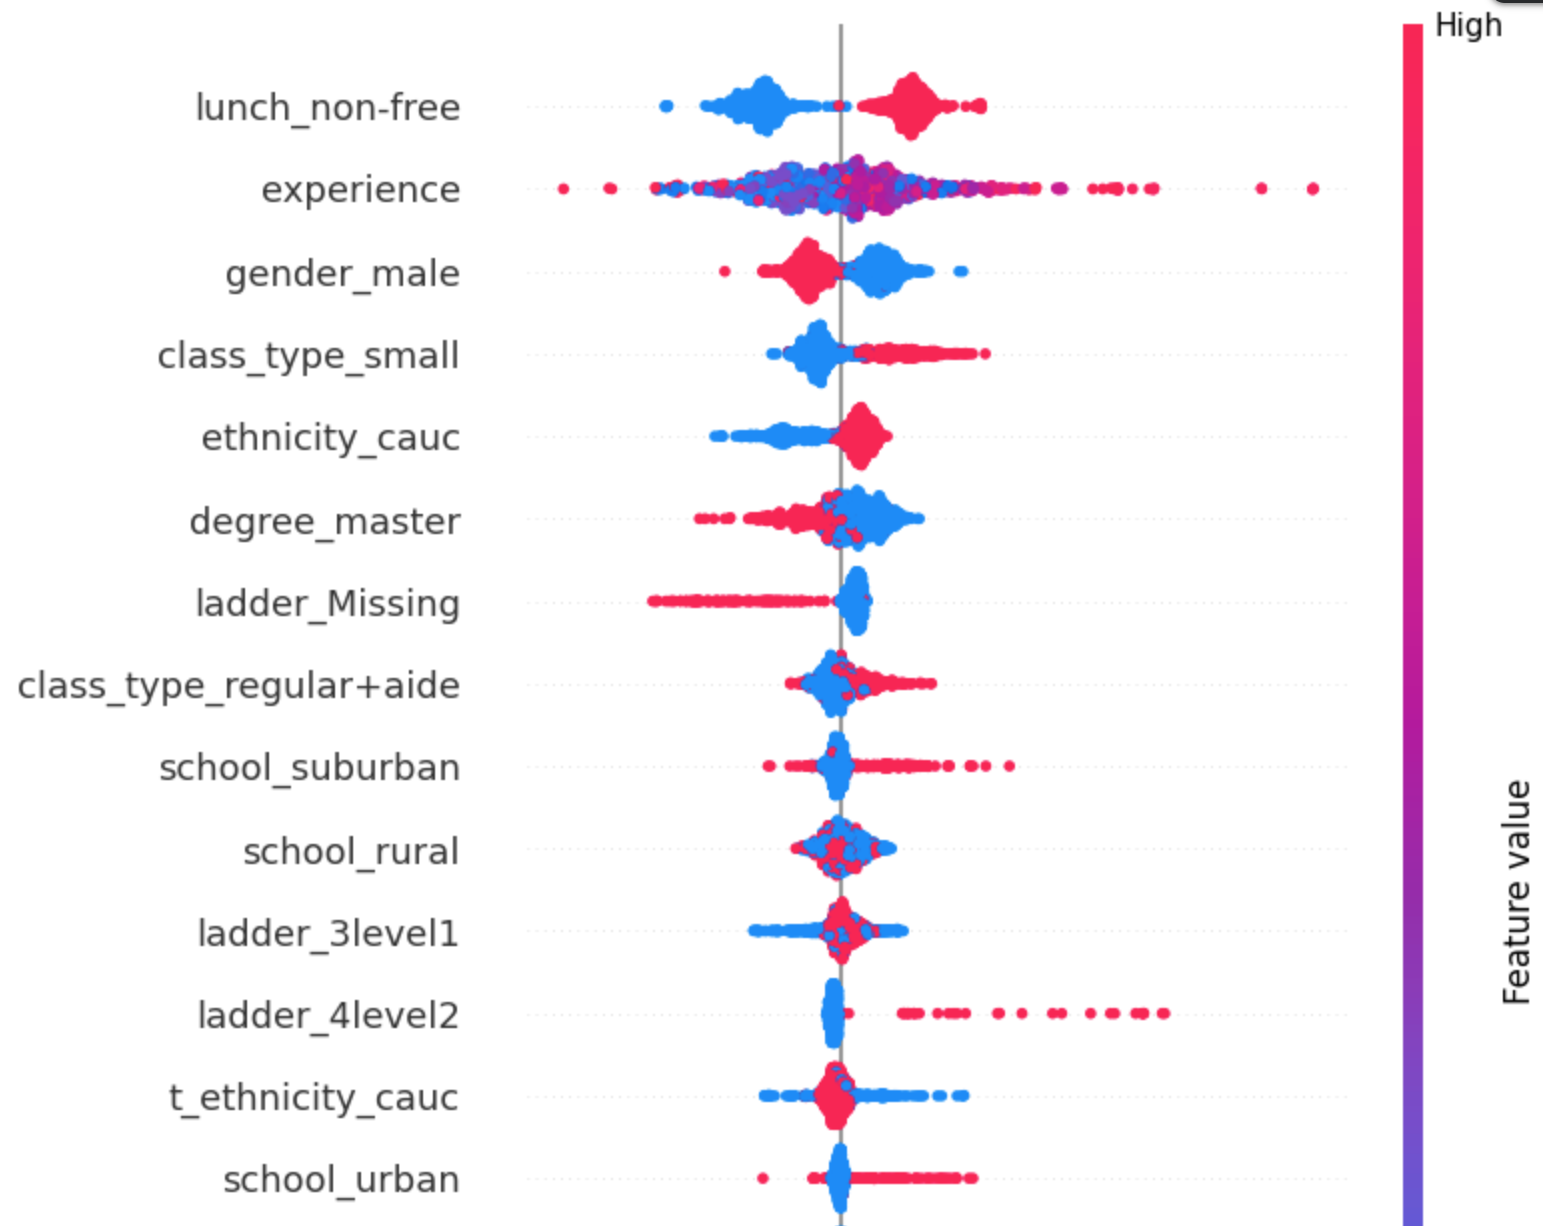

### Selected model (MSE_out)
Code for executing our selected model xgb_read with the out-of-sample 'db_out' MSE

In [ ]:
def data_cleaner_out(df):
    df = df.copy()

    # Drop unnecessary columns
    df = df.drop(["birth", "schooldistrict_id", "school_id"], axis=1)

    # Only fill ladder missing (categorical missing would otherwise create ambiguity)
    ladder_map = {
        "probation": "1probation",
        "apprentice": "2apprentice",
        "level1": "3level1",
        "level2": "4level2",
        "level3": "5level3"
    }

    df["ladder"] = df["ladder"].replace(ladder_map)
    df["ladder"] = df["ladder"].fillna("Missing")
    df["experience"] = df["experience"].fillna(df["experience"].mean())

    df["score_read"] = df["score_read"].fillna(df["score_read"].mean())
    df["score_math"] = df["score_math"].fillna(df["score_math"].mean())

    # Create dummies (including NaN categories)
    df = pd.get_dummies(df, dummy_na=True, drop_first=True)

    
    # Drop all dummy columns representing NaN categories
    # These are named like: variable_nan or variable_NaN
    df = df[[col for col in df.columns if not col.endswith("_nan") and not col.endswith("_NaN")]]

    return df


In [ ]:
# Prepare and cleaned db_out data
cleaned_db_out = data_cleaner_out(db_out)
read_y = cleaned_db_out["score_read"]
math_y = cleaned_db_out["score_math"]
cleaned_db_out = cleaned_db_out.drop(["score_read","score_math"], axis=1)

cleaned_db_out

In [ ]:
xgb_read_out = XGBRegressor(n_estimators=1000,
                         objective="reg:squarederror",
                         random_state=1,
                         **best_params)
xgb_read_out.fit(X=X, y=y)


In [ ]:
read_out = xgb_read_out.predict(cleaned_db_out)

read_mse_out = mean_squared_error(read_y, read_out)

## Modeling of score_math

### OLS for score_math

In [ ]:
# Drop missing values of score_math
db_math = cleaned_data.dropna(subset=['score_math'])

# MAke dammu vars
db_math=pd.get_dummies(db_math, drop_first=True)
db_math.rename(columns={'lunch_non-free': 'lunch_nonfree'}, inplace=True)
db_math.rename(columns={'class_type_regular+aide': 'class_type_regular_aide'}, inplace=True)
db_math.rename(columns={'degree_master+': 'degree_masterplus'}, inplace=True)
db_math.describe(include="all")

In [ ]:
db_math

In [ ]:
selected_cols = ['experience', 'gender_male', 'lunch_nonfree', 'school_urban','school_suburban','school_rural',
                 'degree_master','degree_masterplus', 'degree_specialist','ladder_2apprentice','ladder_3level1',
                 'ladder_4level2','ladder_5level3','t_ethnicity_cauc','class_type_small']
interactions = create_interactions(db_math,selected_cols)
interactions = interactions.drop(columns=[col for col in interactions.columns if col in db_math.columns])
db_math = pd.concat([db_math, interactions], axis=1)
db_math = db_math.drop(columns='score_read')



In [ ]:
# Define X and y
X = db_math.drop(columns=['score_math'])
y = db_math['score_math']

In [ ]:
formula = f'score_math ~ {" + ".join(X.columns)}'
print(formula)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit OLS model full
OLSmodel = ols(formula, data=pd.concat([X_train, y_train], axis=1)).fit()

# Predict and evaluate
y_pred = OLSmodel.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

# Print summary and MSE
print(OLSmodel.summary())
print(f"MSE: {mse}")

### LASSO, Ridge, and ElasticNet

In [ ]:
# Lasso for score_math
train, test = train_test_split(db_math, test_size = 0.3,random_state=1)
response = 'score_math'
numerical_predictors = ['experience','experience_x_gender_male','experience_x_lunch_nonfree','experience_x_school_urban',
                        'experience_x_school_suburban','experience_x_school_rural','experience_x_degree_master',
                        'experience_x_degree_masterplus','experience_x_degree_specialist','experience_x_ladder_2apprentice',
                        'experience_x_ladder_3level1','experience_x_ladder_4level2','experience_x_ladder_5level3',
                        'experience_x_t_ethnicity_cauc']
predictors = [x for x in db_math.columns if x not in response] # the list of all predictors

In [ ]:
mu = train[numerical_predictors].mean() # mean for each feature
sigma = train[numerical_predictors].std() # std for each feature

In [ ]:
train_std = train.copy()
test_std = test.copy()
train_std[numerical_predictors] = (train[numerical_predictors] - mu) / sigma
test_std[numerical_predictors] = (test[numerical_predictors] - mu) / sigma

train_std[numerical_predictors].mean()
train_std[numerical_predictors].std()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

alphas = np.logspace(-3, 2, 100)
lasso_cv = LassoCV(alphas=alphas,cv = 5) #5-fold CV - returns optimal lambda as part of the process
lasso_cv.fit(train_std[predictors],train_std[response])
print(f'LASSO Lambda: {lasso_cv.alpha_}')
# Lasso MSE
y_pred_test = lasso_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")



### Ridge

In [ ]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 2, 100) # grid is on log scale 100 values from 10^-3 to 10^2
ridge_cv = RidgeCV(alphas=alphas, cv = 5)
ridge_cv.fit(train_std[predictors], train_std[response])
print(f'Ridge Lambda: {ridge_cv.alpha_}')
# Ridge mse
y_pred_test = ridge_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")


### ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNetCV
l1_ratio_grid = [0.001, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1]
alphas = np.logspace(-3, 2, 100)
enet_cv = ElasticNetCV(alphas=alphas,l1_ratio = l1_ratio_grid, cv = 5, random_state=1)
enet_cv.fit(train_std[predictors],train_std[response])
print(f'ElasticNet Lambda: {enet_cv.alpha_} l1_ratio: {enet_cv.l1_ratio_}')
# Elsaticnet mse
y_pred_test = enet_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")

Elasticnet suggests we use L1_ratio of 0.99, mostly Lasso with a lambda near that that from optimal lasso lambda

In [ ]:
# Summarize of OLS,lasso,ridge,elasticnet for score_math
columns = ['R-squared', 'Test MSE']
rows = ['OLS','Ridge','LASSO','Elastic Net']

results = pd.DataFrame(0.0, columns=columns, index=rows) # initialising a dataframe to hold the results

methods = [OLSmodel, ridge_cv, lasso_cv, enet_cv]
test_data = [X_test, test_std[predictors], test_std[predictors], test_std[predictors]] # Use scaled data for sklearn models

for row, method, test_X in zip(rows, methods, test_data):
    if row == 'OLS':
        # For OLS, predict directly and calculate metrics
        y_pred = method.predict(test_X)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
    else:
        # For scikit-learn models, predict from the scaled test data and calculate metrics
        y_pred = method.predict(test_X)
        r2 = r2_score(test_std[response], y_pred)
        mse = mean_squared_error(test_std[response], y_pred)

    results.loc[row, 'R-squared'] = r2
    results.loc[row, 'Test MSE'] = mse

results.round(3)

### XGBoost with Interactions

In [ ]:
import xgboost as xgb
import shap

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 5,
    'min_child_weight':8,
    'learning_rate':0.1,
    'subsample': 1.0,
    'colsample_bytree': 1.0
}
model_xg = xgb.XGBRegressor(early_stopping_rounds=10,
                            verbosity=0,
                            **params)
model_xg.fit(X_train, y_train,
             eval_set=[(X_test, y_test)],
             verbose=False)

y_pred_train = model_xg.predict(X_train)
y_pred_test = model_xg.predict(X_test)

print(f"\nTrain R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_test):.2f}")

### Tree regression without Interaction terms

In [ ]:
# Train tree models without interaction terms
# Create dummy vars
math = pd.get_dummies(math, drop_first=True)

# For cv test (require full data)
X = math.drop(columns=[response])
y = math[response]

train, test = train_test_split(math, test_size = 0.3,random_state=1)
response = 'score_math'
X_train = train.drop(columns=[response])
y_train = train[response]

X_test = test.drop(columns=[response])
y_test = test[response]


#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define a metrics function
def metrics(X_test, y_test, model):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    return r2, mse

rf = RandomForestRegressor(n_estimators=1000, max_features ='sqrt', min_samples_leaf=3, random_state=1)
rf.fit(X_train, y_train)
ypred_rf = rf.predict(X_test)
# Scores result
r2_rf, mse_rf = metrics(X_test, y_test, rf)

print(f"Test R²:   {r2_rf}")
print(f"Test MSE:  {mse_rf}")

Woah, so much better than lasso and models above

In [ ]:
rf = RandomForestRegressor(n_estimators=1000, random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [5,6, 7],
    'max_features': ['sqrt', 'log2'],
    "min_samples_leaf": [2,3,4]
    }

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(rf, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)


In [ ]:
# See the r-score and mse for the cv=5 best_params of gbf
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=1000,
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")

results.loc['rf_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]

I guess the rf is overfitting, and once try 5 cv K-folds, the performance is worse. But why is it so much better earlier?? Hyperparameter range is not the optimal range?

#### Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbf = GradientBoostingRegressor(n_estimators=1000, n_iter_no_change=50, learning_rate=0.1,
                                subsample=0.9, max_depth=3, random_state=1)
gbf.fit(X_train, y_train)
ypred_gbf = gbf.predict(X_test)
r2_gbf, mse_gbf = metrics(X_test, y_test, gbf)
print(f"Test R²:   {r2_gbf}")
print(f"Test MSE:  {mse_gbf}")


In [ ]:

gbf = GradientBoostingRegressor(n_estimators=1000, random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.07, 0.09,0.1],
    "subsample": [0.8, 0.9]
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(gbf, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)


In [ ]:
# See the r-score and mse for the cv=5 best_params of gbf
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = GradientBoostingRegressor(n_estimators=1000,
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
results.loc['gbf_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]


#### XgBoost

In [ ]:
# Xgboost with no interaction terms
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 4,
    'min_child_weight':4,
    'learning_rate':0.02,
    'subsample': 0.4,
    'colsample_bytree': 0.6
}
xgb_math = xgb.XGBRegressor(n_estimators=1000,
                            verbosity=0,
                            **params,
                            random_state=1)
xgb_math.fit(X_train, y_train,
             verbose=False)
predictions = xgb_math.predict(X_test)
# Predict and evaluate
y_pred = xgb_math.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
#r2_xgb, mse_xgb = metrics(X_test, y_test, xgb)
# Print summary and MSE
print(f"MSE: {mse}")

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBRegressor

xgb_math = XGBRegressor(n_estimators=1000, objective="reg:squarederror", random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [4,5, 6],
    'min_child_weight':[4,5],
    "learning_rate": [0.02, 0.04, 0.05,0.06],
    "subsample": [0.6, 0.7],
    "colsample_bytree": [0.5, 0.6],
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(xgb_math, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)

In [ ]:
# See the r-score and mse for the cv=5 best_params
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBRegressor(n_estimators=1000,
                         objective="reg:squarederror",
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
results.loc['xgb_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]


In [ ]:
# Show comparison result
results.round(3)

In [ ]:
# SHAP analysis
# Convert boolean columns to numeric (int)
for col in X_test.columns:
   if X_test[col].dtype == 'bool':
       X_test[col] = X_test[col].astype(int)

explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, show=False)

Takes alot of time to run ...so here's a screenshot of the output! Just. like before the cell itself has been commented out.


[image.png](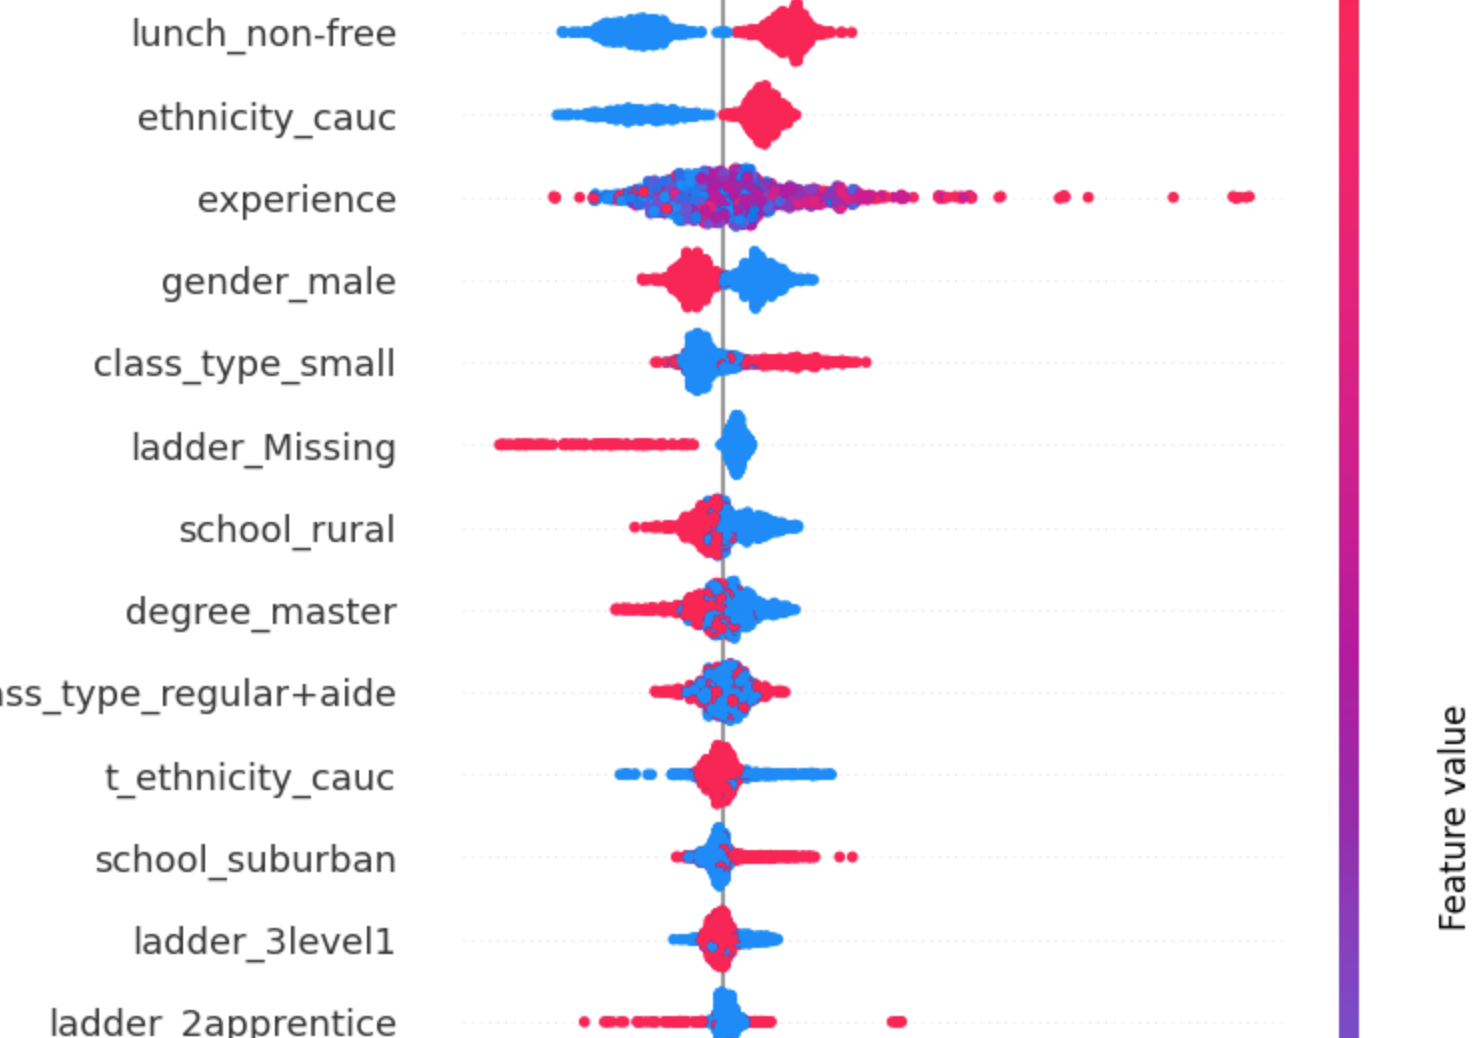)

Code to execute mse_out for db_out for our selected model xgb_math

### Selected model (MSE_out)
Code to executing the mse_out for socre_math

In [ ]:
xgb_math_out = XGBRegressor(n_estimators=1000,
                         objective="reg:squarederror",
                         random_state=1,
                         **best_params)

xgb_math_out.fit(X=X, y=y)

In [ ]:
math_out = xgb_math_out.predict(cleaned_db_out)

math_mse_out = mean_squared_error(math_y, math_out)



## Total MSE
Output the total of mse_out for score_read and score_math

In [ ]:
total_mse = (1/2) * (math_mse_out + read_mse_out)
print(f"Total MSE: {total_mse:.4f}")